# Proyecto práctico: Visualización geoespacial y análisis de datos territoriales

**Módulo 4 — Visualización de datos | Diplomado en Ciencia de Datos**

## Pregunta de investigación

¿Cómo se distribuyen territorialmente la oferta educativa, la matrícula escolar y las condiciones de conectividad/equipamiento en Argentina?

## Objetivos

1. Integrar **múltiples fuentes abiertas** con información georreferenciada y tabular.
2. Realizar **EDA, limpieza y transformación** con criterio de analista de datos.
3. Construir **visualizaciones estáticas e interactivas** con lectura territorial.
4. Documentar decisiones metodológicas y conclusiones.

## Fuentes oficiales utilizadas

| Tabla | Fuente | Rol |
|-------|--------|-----|
| Establecimientos georreferenciados | [Mapa Educativo Nacional (WFS)](https://mapa.educacion.gob.ar/) | Puntos con coordenadas, gestión y ámbito |
| Matrícula y características por escuela | [Relevamiento Anual — Base por Escuela](https://www.datos.gob.ar/dataset/educacion-base-datos-por-escuela-2024) | Indicadores de matrícula y conectividad |
| Límites administrativos | [Georef / IGN](https://apis.datos.gob.ar/georef/api/v2.0/) | Polígonos provinciales y departamentales |
| Indicadores contextuales | [Datos Abiertos — Obras Públicas](https://transparencia.obraspublicas.gob.ar/) | Asistencia escolar y cantidad de establecimientos |

> **Nota sobre el ciclo lectivo:** las bases por escuela 2024 publicadas en [datos.gob.ar](https://www.datos.gob.ar/dataset/educacion-base-datos-por-escuela-2024) están alojadas en SharePoint y requieren descarga manual. Este notebook descarga automáticamente el **paquete CSV del RA 2020** (misma estructura metodológica) desde [argentina.gob.ar](https://www.argentina.gob.ar/educacion/evaluacion-e-informacion-educativa/base-de-datos-por-escuela-2020) y lo combina con el **padrón georreferenciado vigente** del Mapa Educativo Nacional.


## 0. Instalación de dependencias

Esta celda instala los paquetes necesarios.


In [ ]:
import importlib
import subprocess
import sys

DEPENDENCIAS = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'geopandas',
    'folium',
    'requests',
    'shapely',
    'pyproj',
    'mapclassify',
]

def instalar(paquetes):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *paquetes])


faltantes = []
for pkg in DEPENDENCIAS:
    modulo = "folium" if pkg == "folium" else pkg
    try:
        importlib.import_module(modulo)
    except ImportError:
        faltantes.append(pkg)

if faltantes:
    print("Instalando:", ", ".join(faltantes))
    instalar(faltantes)
    print("Dependencias instaladas.")
else:
    print("Todas las dependencias ya están disponibles.")


Todas las dependencias ya están disponibles.


In [ ]:
# Configuración inicial
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from io import BytesIO
import zipfile
import json
import re
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
import requests
from shapely.geometry import Point

# Detectar Google Colab
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False



def resolver_base_dir() -> Path:
    """Ubica la carpeta del proyecto."""
    candidatos = [Path.cwd()]
    if IN_COLAB:
        candidatos = [
            Path('/content/TP_Data_Science'),
            Path('/content'),
            Path.cwd(),
        ] + candidatos
    for base in candidatos:
        if (base / 'data' / 'raw').exists() or (base / 'TP_Visualizacion_datos.ipynb').exists():
            return base.resolve()
    return Path.cwd().resolve()


BASE_DIR = resolver_base_dir()
DATA_DIR = BASE_DIR / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
for d in [RAW_DIR, PROCESSED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if IN_COLAB:
    os.chdir(BASE_DIR)


# URLs oficiales
URLS = {
    'bases_ra_csv_zip': 'https://www.argentina.gob.ar/sites/default/files/2018/04/bases_usuarias_en_formato_csv.zip',
    'wfs_establecimientos': (
        'https://mapa.educacion.gob.ar/geoserver/ows?service=WFS&version=1.1.0'
        '&request=GetFeature&typeName=publico:establecimiento_educativo&outputFormat=application/json'
    ),
    'provincias_geojson': 'https://apis.datos.gob.ar/georef/api/v2.0/provincias.geojson',
    'departamentos_geojson': 'https://apis.datos.gob.ar/georef/api/v2.0/departamentos.geojson',
    'asistencia_escolar': 'https://transparencia.obraspublicas.gob.ar/hogurb_ninxs5a14_asisescolar.csv',
    'cant_establecimientos': 'https://transparencia.obraspublicas.gob.ar/cant-esteducativos.csv',
}

# Homologación de nombres provinciales (CSV educación ↔ Georef)
PROVINCIA_MAP = {
    'Ciudad de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Tierra del Fuego': 'Tierra del Fuego, Antártida e Islas del Atlántico Sur',
}

entorno = 'Google Colab' if IN_COLAB else 'local'
print(f'Entorno: {entorno}')
print(f'Directorio base: {BASE_DIR}')
print(f'Datos en: {RAW_DIR}')


Entorno: Google Colab
Directorio base: /content
Datos en: /content/data/raw


In [ ]:
def descargar(url: str, destino: Path, force: bool = False, timeout: int = 300) -> Path:
    """Descarga un recurso HTTP si no existe localmente."""
    destino.parent.mkdir(parents=True, exist_ok=True)
    if destino.exists() and destino.stat().st_size > 0 and not force:
        print(f'[cache] {destino.name}')
        return destino
    print(f'[download] {url}')
    with requests.get(url, timeout=timeout, stream=True) as r:
        r.raise_for_status()
        with open(destino, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
    size_mb = destino.stat().st_size / 1e6
    print(f'  -> guardado: {destino} ({size_mb:.1f} MB)')
    return destino


def cargar_csv_educacion(nombre_archivo: str) -> pd.DataFrame:
    """Lee un CSV del RA desde data/raw o desde el ZIP oficial."""
    local = RAW_DIR / nombre_archivo
    if local.exists():
        return pd.read_csv(local, sep=';', encoding='latin-1', low_memory=False)
    zip_path = descargar(URLS['bases_ra_csv_zip'], RAW_DIR / 'bases_usuarias_en_formato_csv.zip')
    with zipfile.ZipFile(zip_path) as zf:
        with zf.open(nombre_archivo) as f:
            return pd.read_csv(f, sep=';', encoding='latin-1', low_memory=False)


def cargar_geojson(url: str, cache_name: str) -> gpd.GeoDataFrame:
    path = RAW_DIR / cache_name
    if not path.exists() or path.stat().st_size == 0:
        descargar(url, path)
    return gpd.read_file(path)


def verificar_datos(force: bool = False) -> None:
    """Descarga todos los insumos si el equipo no incluyó la carpeta data/."""
    archivos = {
        'bases_usuarias_en_formato_csv.zip': URLS['bases_ra_csv_zip'],
        'establecimientos_educativos.geojson': URLS['wfs_establecimientos'],
        'provincias.geojson': URLS['provincias_geojson'],
        'departamentos.geojson': URLS['departamentos_geojson'],
        'asistencia_escolar.csv': URLS['asistencia_escolar'],
        'cant_establecimientos.csv': URLS['cant_establecimientos'],
    }
    for nombre, url in archivos.items():
        descargar(url, RAW_DIR / nombre, force=force)


# Descarga automática de insumos (usa cache si ya existen)
verificar_datos(force=False)

# --- Tabla 1: establecimientos georreferenciados (WFS) ---
wfs_path = RAW_DIR / 'establecimientos_educativos.geojson'
gdf_escuelas = gpd.read_file(wfs_path)
print('Establecimientos WFS:', gdf_escuelas.shape)

# --- Tabla 2: matrícula por escuela ---
df_matricula = cargar_csv_educacion('Base 2- Matrícula.csv')
print('Matrícula por escuela:', df_matricula.shape)

# --- Tabla 3: características / conectividad ---
df_caracteristicas = cargar_csv_educacion('Base 5- Características.csv')
print('Características por escuela:', df_caracteristicas.shape)

# --- Tabla 4 y 5: límites administrativos ---
gdf_provincias = cargar_geojson(URLS['provincias_geojson'], 'provincias.geojson')
gdf_departamentos = cargar_geojson(URLS['departamentos_geojson'], 'departamentos.geojson')
print('Provincias:', gdf_provincias.shape, '| Departamentos:', gdf_departamentos.shape)

# --- Tabla 6: indicadores contextuales provinciales ---
df_asistencia = pd.read_csv(RAW_DIR / 'asistencia_escolar.csv')
df_cant_est = pd.read_csv(RAW_DIR / 'cant_establecimientos.csv')
print('Asistencia escolar:', df_asistencia.shape, '| Cant. establecimientos:', df_cant_est.shape)



[download] https://www.argentina.gob.ar/sites/default/files/2018/04/bases_usuarias_en_formato_csv.zip
  -> guardado: /content/data/raw/bases_usuarias_en_formato_csv.zip (12.0 MB)
[download] https://mapa.educacion.gob.ar/geoserver/ows?service=WFS&version=1.1.0&request=GetFeature&typeName=publico:establecimiento_educativo&outputFormat=application/json
  -> guardado: /content/data/raw/establecimientos_educativos.geojson (36.5 MB)
[download] https://apis.datos.gob.ar/georef/api/v2.0/provincias.geojson
  -> guardado: /content/data/raw/provincias.geojson (0.6 MB)
[download] https://apis.datos.gob.ar/georef/api/v2.0/departamentos.geojson
  -> guardado: /content/data/raw/departamentos.geojson (1.2 MB)
[download] https://transparencia.obraspublicas.gob.ar/hogurb_ninxs5a14_asisescolar.csv
  -> guardado: /content/data/raw/asistencia_escolar.csv (0.0 MB)
[download] https://transparencia.obraspublicas.gob.ar/cant-esteducativos.csv
  -> guardado: /content/data/raw/cant_establecimientos.csv (0.0 MB)


## 2. Inspección inicial (EDA preliminar)

Revisamos estructura, tipos, nulos y cobertura territorial antes de transformar.


In [ ]:
def resumen_tabla(df, nombre):
    print('=' * 60)
    print(nombre)
    print('Dimensiones:', df.shape)
    display(df.head(3))
    nulos = df.isna().mean().sort_values(ascending=False)
    print('\nTop 10 columnas con mayor % de nulos:')
    display((nulos.head(10) * 100).round(1).to_frame('% nulos'))

resumen_tabla(gdf_escuelas.drop(columns='geometry'), 'Establecimientos georreferenciados')
resumen_tabla(df_matricula, 'Matrícula por escuela')
resumen_tabla(df_caracteristicas, 'Características por escuela')


Establecimientos georreferenciados
Dimensiones: (64639, 13)


,id,gid,fna,gna,nam,fun,cue,amg,ges,mde,nen,sag,pre
0,establecimiento_educativo.fid-783df2ed_19f0ade...,43366,INSTITUTO PRIVADO ESCUELA EVANGELICA WILLIAM C...,INSTITUTO PRIVADO,ESCUELA EVANGELICA WILLIAM C. MORRIS,Activo,020000100,Urbano,Privado,Común;,Común-Secundaria-Ambos Ciclos;,Mapa Educativo Nacional - DIEE,PRECISA
1,establecimiento_educativo.fid-783df2ed_19f0ade...,496759,None,None,None,Activo,020000102,Urbano,Privado,Común;,Común-Escuela Infantil; Común-Primaria 7años;,None,PRECISA
2,establecimiento_educativo.fid-783df2ed_19f0ade...,43301,CARLOS R. VIGNALE,,CARLOS R. VIGNALE,Activo,020000200,Urbano,Estatal,Común;,Común-Primaria 7años;,Mapa Educativo Nacional - DIEE,PRECISA



Top 10 columnas con mayor % de nulos:


,% nulos
gna,2.9
nam,2.5
fna,2.1
sag,2.1
id,0.0
gid,0.0
fun,0.0
amg,0.0
cue,0.0
ges,0.0


Matrícula por escuela
Dimensiones: (49385, 111)


...

,% nulos
s_lactantes,99.9
s_deambulantes,99.8
secundaria_orientada,99.8
s_s3,99.5
s_s2,99.5
secundaria_cb7,98.9
lactantes,98.7
v_lactantes,98.7
snu_inet,98.7
s_s4,98.6


Características por escuela
Dimensiones: (49818, 64)


,ID1,provincia,sector,ambito,Electricidad - Si,Electricidad - Red pública,Electricidad - Grupo electrógeno,Electricidad - Panel fotovoltaico/solar,Electricidad - Generador eólico,Electricidad - Generador hidráulico,...,Sistema de Gestión Escolar - Planilla de Calculo,Dispone de sala o laboratorio de informática - Si,Laboratorio - Funciona es espacio exclusivo? - Si,Biblioteca - Dispone de al menos una? - Si,Biblioteca - Funciona es espacio exclusivo? - Si,Subvención Estatal - Jardín Maternal - Si,Subvención Estatal - Jardín de Infantes - Si,Subvención Estatal - Primaria - Si,Subvención Estatal - Secundaria - Si,Subvención Estatal - SNU - Si
0,20004002000400,Mendoza,Estatal,Urbano,X,X,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20008002000800,Mendoza,Privado,Urbano,X,X,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21604002160400,Misiones,Estatal,Urbano,X,X,NaN,NaN,NaN,NaN,...,NaN,X,X,X,X,NaN,NaN,NaN,NaN,NaN



Top 10 columnas con mayor % de nulos:


,% nulos
Equipamiento Establecimiento - Equipo receptor de radio AM/FM,100.0
Equipamiento Biblioteca - Equipo receptor de radio AM/FM,100.0
Electricidad - Generador eólico,99.9
Electricidad - Generador hidráulico,99.9
Subvención Estatal - SNU - Si,98.7
Subvención Estatal - Jardín Maternal - Si,98.5
Electricidad - Grupo electrógeno,98.0
Sistema de Gestión Escolar - Encargado por el Establecimiento,97.8
Sistema de Gestión Escolar - Planilla de Calculo,97.5
Electricidad - Panel fotovoltaico/solar,97.4


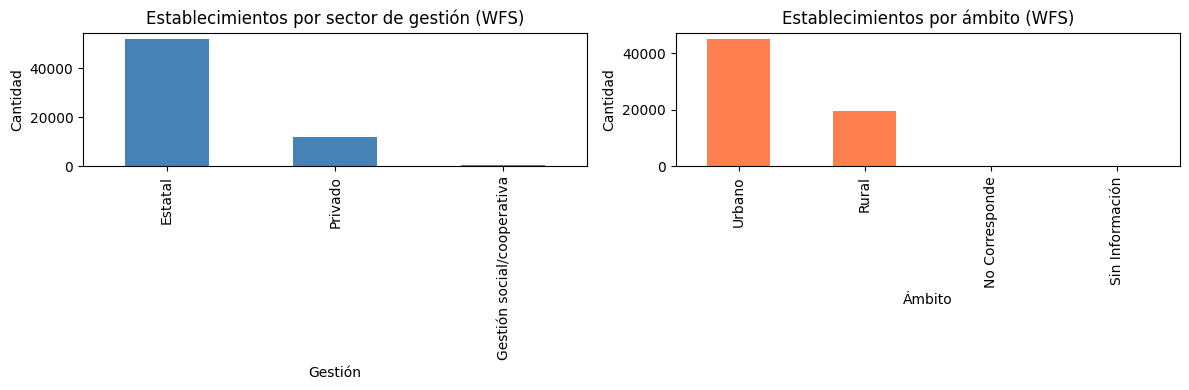

In [ ]:
# Distribución de gestión y ámbito en el padrón georreferenciado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gdf_escuelas['ges'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Establecimientos por sector de gestión (WFS)')
axes[0].set_xlabel('Gestión'); axes[0].set_ylabel('Cantidad')

gdf_escuelas['amg'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Establecimientos por ámbito (WFS)')
axes[1].set_xlabel('Ámbito'); axes[1].set_ylabel('Cantidad')
plt.tight_layout(); plt.show()


### 2.1 Tratamiento de datos nulos y valores faltantes

En las bases del Relevamiento Anual, los nulos suelen significar **“no aplica a este establecimiento”** (p. ej. un jardín sin secundaria) o **“no informado”** en equipamiento. Aplicamos reglas explícitas por tipo de variable:

| Tipo de variable | Tratamiento | Justificación |
|------------------|-------------|---------------|
| Matrícula por nivel/modalidad | Se conservan nulos en columnas individuales; `matricula_total` suma con `skipna=True` | El nivel puede no existir en la escuela |
| Equipamiento / conectividad | Nulo → `0` (ausencia) vía `flag_binario` | Sin respuesta implica que no declara el servicio |
| Categóricas clave (`sector`, `ambito`, `provincia`) | Eliminación de filas con nulos | Son variables obligatorias para el análisis territorial |
| Geometría / coordenadas | Exclusión de registros sin punto válido o fuera de Argentina | Evita errores en joins espaciales |
| Join matrícula + características | `fillna` cruzado entre tablas para provincia/sector/ámbito | Completar desde la tabla hermana si falta en una |
| Agregaciones territoriales | `fillna(0)` en conteos departamentales sin escuelas | Departamento sin registros = cero establecimientos |



=== Matrícula — antes ===
Sin nulos en columnas analizadas.
Filas totales: 49,385 | Filas con al menos 1 nulo: 0

=== Características — antes ===
Sin nulos en columnas analizadas.
Filas totales: 49,818 | Filas con al menos 1 nulo: 0

=== WFS — antes ===


,% nulos
nam,2.53
fna,2.12


Filas totales: 64,639 | Filas con al menos 1 nulo: 1,634


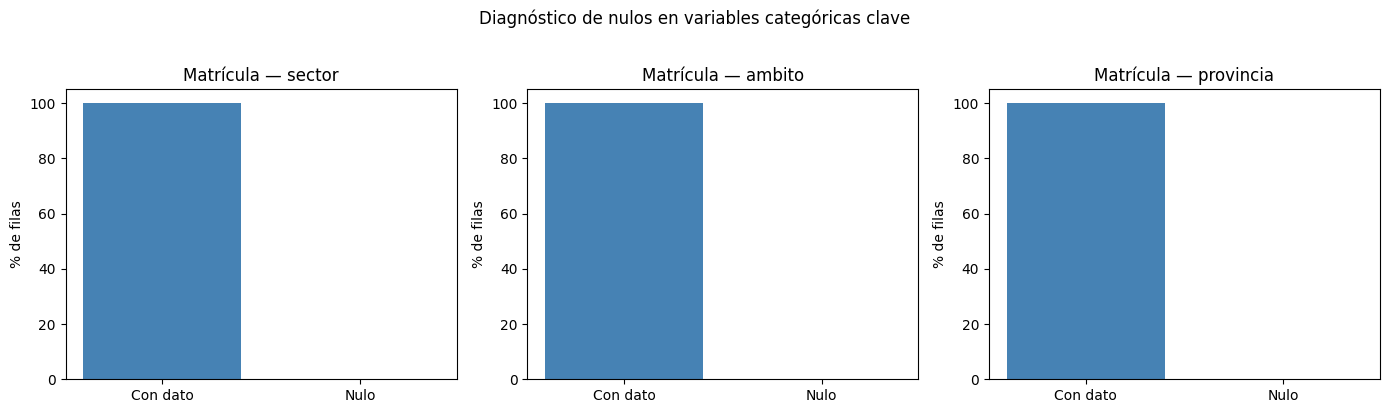

In [ ]:
def reporte_nulos(df, nombre, columnas=None):
    """Resumen compacto de nulos por columna."""
    cols = columnas or df.columns
    rep = df[cols].isna().mean().mul(100).round(2).sort_values(ascending=False)
    rep = rep[rep > 0].to_frame("% nulos")
    print(f"\n=== {nombre} ===")
    if rep.empty:
        print("Sin nulos en columnas analizadas.")
    else:
        display(rep.head(15))
    print(f"Filas totales: {len(df):,} | Filas con al menos 1 nulo: {df[cols].isna().any(axis=1).sum():,}")
    return rep


# --- Diagnóstico previo al tratamiento ---
cat_cols_mat = ["provincia", "sector", "ambito"]
cat_cols_car = ["provincia"]
reporte_nulos(df_matricula, "Matrícula — antes", cat_cols_mat)
reporte_nulos(df_caracteristicas, "Características — antes", cat_cols_car)
reporte_nulos(gdf_escuelas.drop(columns="geometry"), "WFS — antes", ["ges", "amg", "nam", "fna", "fun"])

# Visualización de nulos en variables clave
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, df_, title in zip(
    axes,
    ["sector", "ambito", "provincia"],
    [df_matricula, df_matricula, df_matricula],
    ["sector", "ambito", "provincia"],
):
    pct = df_[col].isna().mean() * 100
    ax.bar(["Con dato", "Nulo"], [100 - pct, pct], color=["steelblue", "salmon"])
    ax.set_title(f"Matrícula — {title}")
    ax.set_ylabel("% de filas")
plt.suptitle("Diagnóstico de nulos en variables categóricas clave", y=1.02)
plt.tight_layout()
plt.show()


## 3. Preprocesamiento y limpieza

### Decisiones metodológicas

1. **Normalización de nombres** de columnas y provincias para permitir joins territoriales.
2. **Codificación binaria** de variables de equipamiento/conectividad (presencia = 1).
3. **Imputación conservadora**: valores faltantes en indicadores de servicios se interpretan como ausencia (`0`).
4. **Eliminación selectiva**: filas sin `provincia`, `sector` o `ambito`, o con `matricula_total` nula/cero.
5. **Filtrado espacial**: registros sin geometría válida o fuera del bounding box argentino.
6. **Deduplicación** por `id1` en tablas del Relevamiento Anual.
7. **CRS único**: reproyección a `EPSG:4326` (WGS84) para mapas web y análisis espacial.


In [ ]:
def normalizar_provincia(serie: pd.Series) -> pd.Series:
    return serie.astype(str).str.strip().replace(PROVINCIA_MAP)


def estandarizar_columnas(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = (
        out.columns.str.strip()
        .str.lower()
        .str.replace(r'[^a-z0-9]+', '_', regex=True)
        .str.strip('_')
    )
    return out


def flag_binario(serie: pd.Series) -> pd.Series:
    """Convierte respuestas del RA a binario (1=presente). Nulos -> 0 (ausencia)."""
    if serie.dtype == 'object':
        return serie.fillna('').astype(str).str.strip().str.lower().isin(['1', 'si', 'sí', 'x', 'true']).astype(int)
    return serie.fillna(0).astype(float).gt(0).astype(int)


def limpiar_categoricas(df: pd.DataFrame, columnas: list[str], nombre: str) -> pd.DataFrame:
    antes = len(df)
    out = df.dropna(subset=columnas).copy()
    for col in columnas:
        out = out[out[col].astype(str).str.strip().ne('')]
        out = out[~out[col].astype(str).str.lower().isin(['nan', 'none', 'null'])]
    eliminadas = antes - len(out)
    print(f'{nombre}: {eliminadas:,} filas eliminadas por nulos/vacíos en {columnas} ({eliminadas/antes*100:.2f}%)')
    return out


# --- Limpieza WFS ---
gdf_escuelas = gdf_escuelas.copy()
n_wfs_ini = len(gdf_escuelas)
gdf_escuelas = gdf_escuelas[gdf_escuelas.geometry.notna()].copy()
gdf_escuelas = gdf_escuelas.to_crs(epsg=4326)

minx, miny, maxx, maxy = -73.6, -55.2, -53.0, -21.8
gdf_escuelas = gdf_escuelas.cx[minx:maxx, miny:maxy]
gdf_escuelas['gestion'] = gdf_escuelas['ges'].fillna('No informado').astype(str).str.strip()
gdf_escuelas['ambito'] = gdf_escuelas['amg'].fillna('No informado').astype(str).str.strip()
gdf_escuelas['nombre_est'] = gdf_escuelas['nam'].fillna(gdf_escuelas['fna']).fillna('Sin nombre')
gdf_escuelas['activo'] = gdf_escuelas['fun'].fillna('').astype(str).str.contains('Activo', case=False, na=False)
print(f'WFS: {n_wfs_ini - len(gdf_escuelas):,} registros excluidos por geometría inválida o fuera de Argentina')

# --- Limpieza tabular educación ---
df_matricula = estandarizar_columnas(df_matricula)
df_caracteristicas = estandarizar_columnas(df_caracteristicas)

df_matricula = limpiar_categoricas(df_matricula, ['provincia', 'sector', 'ambito'], 'Matrícula')
df_caracteristicas = limpiar_categoricas(df_caracteristicas, ['provincia'], 'Características')

df_matricula['provincia_norm'] = normalizar_provincia(df_matricula['provincia'])
df_caracteristicas['provincia_norm'] = normalizar_provincia(df_caracteristicas['provincia'])

id_cols = {'id1'}
mat_num_cols = [
    c for c in df_matricula.columns
    if c not in id_cols.union({'provincia', 'sector', 'ambito', 'provincia_norm'})
    and pd.api.types.is_numeric_dtype(df_matricula[c])
]
df_matricula['matricula_total'] = df_matricula[mat_num_cols].sum(axis=1, skipna=True)

# Escuelas sin matrícula declarada en ningún nivel -> excluir del análisis de matrícula
n_sin_mat = (df_matricula['matricula_total'] <= 0).sum()
df_matricula = df_matricula[df_matricula['matricula_total'] > 0].copy()
print(f'Matrícula: {n_sin_mat:,} escuelas excluidas por matricula_total nula o cero')

# Duplicados por identificador
dup_mat = df_matricula.duplicated(subset=['id1']).sum()
dup_car = df_caracteristicas.duplicated(subset=['id1']).sum()
df_matricula = df_matricula.drop_duplicates(subset=['id1'], keep='first')
df_caracteristicas = df_caracteristicas.drop_duplicates(subset=['id1'], keep='first')
print(f'Duplicados eliminados — Matrícula: {dup_mat:,} | Características: {dup_car:,}')

# Flags de conectividad (nulos = sin servicio)
inet_cols = [c for c in df_caracteristicas.columns if c.startswith('internet')]
for c in inet_cols:
    df_caracteristicas[c + '_flag'] = flag_binario(df_caracteristicas[c])

df_caracteristicas['tiene_internet'] = df_caracteristicas[[c + '_flag' for c in inet_cols]].max(axis=1)
movil_col = [c for c in df_caracteristicas.columns if 'internet' in c and 'm_vil' in c and c.endswith('_flag')]
adsl_col = [c for c in df_caracteristicas.columns if 'internet' in c and 'adsl' in c and c.endswith('_flag')]
df_caracteristicas['internet_movil'] = df_caracteristicas[movil_col[0]] if movil_col else 0
df_caracteristicas['internet_adsl'] = df_caracteristicas[adsl_col[0]] if adsl_col else 0

# Merge escuela-level: matrícula + características
df_escuelas_tab = df_matricula.merge(
    df_caracteristicas[['id1', 'provincia_norm', 'sector', 'ambito', 'tiene_internet', 'internet_movil', 'internet_adsl']],
    on='id1', how='inner', suffixes=('_mat', '_car')
)
df_escuelas_tab['provincia_norm'] = df_escuelas_tab['provincia_norm_mat'].fillna(df_escuelas_tab['provincia_norm_car'])
df_escuelas_tab['sector'] = df_escuelas_tab['sector_mat'].fillna(df_escuelas_tab['sector_car'])
df_escuelas_tab['ambito'] = df_escuelas_tab['ambito_mat'].fillna(df_escuelas_tab['ambito_car'])

# Imputación final en indicadores binarios (por seguridad)
for col in ['tiene_internet', 'internet_movil', 'internet_adsl']:
    df_escuelas_tab[col] = df_escuelas_tab[col].fillna(0).astype(int)

print('\nRegistros integrados a nivel escuela:', df_escuelas_tab.shape)
print('Matrícula total nacional:', f"{df_escuelas_tab['matricula_total'].sum():,.0f}")
print('Escuelas con internet (proxy):', f"{df_escuelas_tab['tiene_internet'].mean()*100:.1f}%")

# --- Validación posterior al tratamiento ---
reporte_nulos(df_escuelas_tab, 'Tabla integrada — después', ['provincia_norm', 'sector', 'ambito', 'matricula_total', 'tiene_internet'])



WFS: 1 registros excluidos por geometría inválida o fuera de Argentina
Matrícula: 0 filas eliminadas por nulos/vacíos en ['provincia', 'sector', 'ambito'] (0.00%)
Características: 0 filas eliminadas por nulos/vacíos en ['provincia'] (0.00%)
Matrícula: 46 escuelas excluidas por matricula_total nula o cero
Duplicados eliminados — Matrícula: 0 | Características: 0

Registros integrados a nivel escuela: (49339, 122)
Matrícula total nacional: 18,592,995
Escuelas con internet (proxy): 75.0%

=== Tabla integrada — después ===
Sin nulos en columnas analizadas.
Filas totales: 49,339 | Filas con al menos 1 nulo: 0


,% nulos


### 4.0 Validación de uniones (chequeo de filas y columnas)

Antes de confiar en cualquier `merge`/`join` espacial o tabular, conviene verificar **cuántas filas se pierden o duplican** y si las claves usadas matchean como se espera. Esto evita errores silenciosos (ej: provincias mal normalizadas que no matchean y desaparecen del análisis sin que nadie lo note).

In [ ]:
def validar_merge(df_izq, df_der, df_resultado, clave_izq, clave_der, nombre="merge"):
    """Chequeo rápido de un merge: filas perdidas, duplicadas y claves sin match.

    Parametros
    ----------
    df_izq, df_der : DataFrames originales antes del merge
    df_resultado   : DataFrame resultante del merge
    clave_izq, clave_der : nombres de columna usados como clave en cada lado
    nombre : etiqueta para identificar el reporte en la salida
    """
    print('=' * 70)
    print(f'Validación de unión: {nombre}')
    print('=' * 70)

    n_izq, n_der, n_res = len(df_izq), len(df_der), len(df_resultado)
    print(f'Filas df izquierdo : {n_izq}')
    print(f'Filas df derecho   : {n_der}')
    print(f'Filas resultado    : {n_res}')

    # Filas que se perdieron respecto al esperable (asumiendo join 1 a 1 o N a 1)
    if n_res < n_izq:
        print(f'⚠️  Se perdieron {n_izq - n_res} filas del lado izquierdo respecto al original.')
    if n_res > max(n_izq, n_der):
        print(f'⚠️  El resultado tiene MÁS filas que ambos lados de origen: probable explosión por duplicados en la clave.')

    # Claves que no matchearon (quedaron afuera del resultado)
    claves_izq = set(df_izq[clave_izq].astype(str).str.strip().str.upper())
    claves_der = set(df_der[clave_der].astype(str).str.strip().str.upper())
    sin_match_izq = claves_izq - claves_der
    sin_match_der = claves_der - claves_izq

    print(f'Claves únicas izquierda : {len(claves_izq)}')
    print(f'Claves únicas derecha   : {len(claves_der)}')
    print(f'Claves sin match (izq -> no está en der): {len(sin_match_izq)}')
    if sin_match_izq:
        ejemplo = list(sin_match_izq)[:5]
        print(f'   Ejemplos: {ejemplo}')
    print(f'Claves sin match (der -> no está en izq): {len(sin_match_der)}')
    if sin_match_der:
        ejemplo = list(sin_match_der)[:5]
        print(f'   Ejemplos: {ejemplo}')

    # Duplicados de clave dentro de cada lado (riesgo de explosión en el merge)
    dup_izq = df_izq[clave_izq].duplicated().sum()
    dup_der = df_der[clave_der].duplicated().sum()
    if dup_izq:
        print(f'⚠️  La clave izquierda tiene {dup_izq} valores duplicados.')
    if dup_der:
        print(f'⚠️  La clave derecha tiene {dup_der} valores duplicados.')

    print()
    return {
        'filas_izq': n_izq, 'filas_der': n_der, 'filas_resultado': n_res,
        'sin_match_izq': sin_match_izq, 'sin_match_der': sin_match_der,
        'duplicados_izq': dup_izq, 'duplicados_der': dup_der,
    }


## 4. Transformación e integración geoespacial

1. **Join espacial**: cada establecimiento del WFS se asigna a su departamento y provincia oficial (IGN/Georef).
2. **Agregación provincial/departamental** de matrícula, conectividad y cantidad de escuelas.
3. **Enriquecimiento** con indicadores contextuales de asistencia escolar.


In [ ]:
# Preparar capas administrativas
gdf_provincias = gdf_provincias.copy()
gdf_departamentos = gdf_departamentos.copy()
gdf_provincias['nombre'] = gdf_provincias['nombre'].astype(str).str.strip()
gdf_departamentos['nombre'] = gdf_departamentos['nombre'].astype(str).str.strip()

# Georef devuelve provincia como objeto anidado {id, nombre, ...}
gdf_departamentos['provincia_nombre'] = gdf_departamentos['provincia'].apply(
    lambda x: x['nombre'] if isinstance(x, dict) else str(x)
)

# Join espacial escuelas → departamento
gdf_escuelas_dep = gpd.sjoin(
    gdf_escuelas,
    gdf_departamentos[['nombre', 'provincia_nombre', 'geometry']],
    how='left', predicate='within'
).rename(columns={'nombre': 'departamento', 'provincia_nombre': 'provincia_geo'})

# Si algún punto cae fuera (frontera), usar provincia por punto en polígono provincial
sin_dep = gdf_escuelas_dep['departamento'].isna()
if sin_dep.any():
    fix = gpd.sjoin(gdf_escuelas_dep.loc[sin_dep, ['geometry']], gdf_provincias[['nombre', 'geometry']], how='left', predicate='within')
    gdf_escuelas_dep.loc[sin_dep, 'provincia_geo'] = fix['nombre'].values

print('Escuelas asignadas a departamento:', f"{gdf_escuelas_dep['departamento'].notna().mean()*100:.1f}%")

# Agregación provincial desde WFS
prov_wfs = (
    gdf_escuelas_dep.groupby('provincia_geo')
    .agg(
        n_escuelas_wfs=('cue', 'count'),
        pct_privado=('gestion', lambda s: (s == 'Privado').mean()),
        pct_rural=('ambito', lambda s: (s == 'Rural').mean()),
    )
    .reset_index()
)

# Agregación provincial desde RA (matrícula + internet)
prov_ra = (
    df_escuelas_tab.groupby('provincia_norm')
    .agg(
        n_escuelas_ra=('id1', 'count'),
        matricula_total=('matricula_total', 'sum'),
        matricula_promedio=('matricula_total', 'mean'),
        pct_internet=('tiene_internet', 'mean'),
        pct_internet_movil=('internet_movil', 'mean'),
        pct_estatal=('sector', lambda s: (s.str.lower() == 'estatal').mean()),
        pct_rural_ra=('ambito', lambda s: (s.str.lower() == 'rural').mean()),
    )
    .reset_index()
)

# Unir con geometría provincial
gdf_prov_ind = gdf_provincias.merge(
    prov_wfs, left_on='nombre', right_on='provincia_geo', how='left'
).merge(
    prov_ra, left_on='nombre', right_on='provincia_norm', how='left'
)

# Indicador compuesto: matrícula por escuela en el territorio
gdf_prov_ind['matricula_por_escuela'] = gdf_prov_ind['matricula_total'] / gdf_prov_ind['n_escuelas_ra']

# Agregación departamental (WFS)
dep_ind = (
    gdf_escuelas_dep.dropna(subset=['departamento'])
    .groupby(['provincia_geo', 'departamento'])
    .agg(n_escuelas=('cue', 'count'), pct_privado=('gestion', lambda s: (s == 'Privado').mean()))
    .reset_index()
)

gdf_dep_ind = gdf_departamentos.merge(
    dep_ind,
    left_on=['provincia_nombre', 'nombre'],
    right_on=['provincia_geo', 'departamento'],
    how='left'
)
gdf_dep_ind['n_escuelas'] = gdf_dep_ind['n_escuelas'].fillna(0)

print('Indicadores provinciales listos:', gdf_prov_ind.shape)
print('Indicadores departamentales listos:', gdf_dep_ind.shape)


Escuelas asignadas a departamento: 99.7%
Indicadores provinciales listos: (24, 22)
Indicadores departamentales listos: (529, 13)


In [ ]:
# Indicadores contextuales: asistencia escolar provincial
# Columnas con código de provincia Georef (ej: hogurb_ninxs5a14_asisescolar_6)
ultimo = df_asistencia.sort_values('indice_tiempo').iloc[-1]
asis_cols = [c for c in df_asistencia.columns if c.startswith('hogurb_ninxs5a14_asisescolar_') and c.split('_')[-1].isdigit()]

codigos = {c.split('_')[-1]: ultimo[c] for c in asis_cols}
df_asis_prov = pd.DataFrame({'provincia_id': list(codigos.keys()), 'tasa_asistencia_5_14': list(codigos.values())})
df_asis_prov['provincia_id'] = df_asis_prov['provincia_id'].astype(str)

gdf_provincias_id = gdf_provincias.copy()
gdf_provincias_id['provincia_id'] = gdf_provincias_id['id'].astype(str)
gdf_prov_ind = gdf_prov_ind.merge(
    gdf_provincias_id[['nombre', 'provincia_id']], on='nombre', how='left'
).merge(df_asis_prov, on='provincia_id', how='left')

# Guardar capas procesadas
gdf_prov_ind.to_file(PROCESSED_DIR / 'indicadores_provinciales.geojson', driver='GeoJSON')
gdf_dep_ind.to_file(PROCESSED_DIR / 'indicadores_departamentales.geojson', driver='GeoJSON')
df_escuelas_tab.to_csv(PROCESSED_DIR / 'escuelas_integradas.csv', index=False)

print('Datos procesados guardados en', PROCESSED_DIR)


Datos procesados guardados en /content/data/processed


## 5. Análisis exploratorio (EDA)

Exploramos relaciones entre matrícula, conectividad, gestión y ámbito.


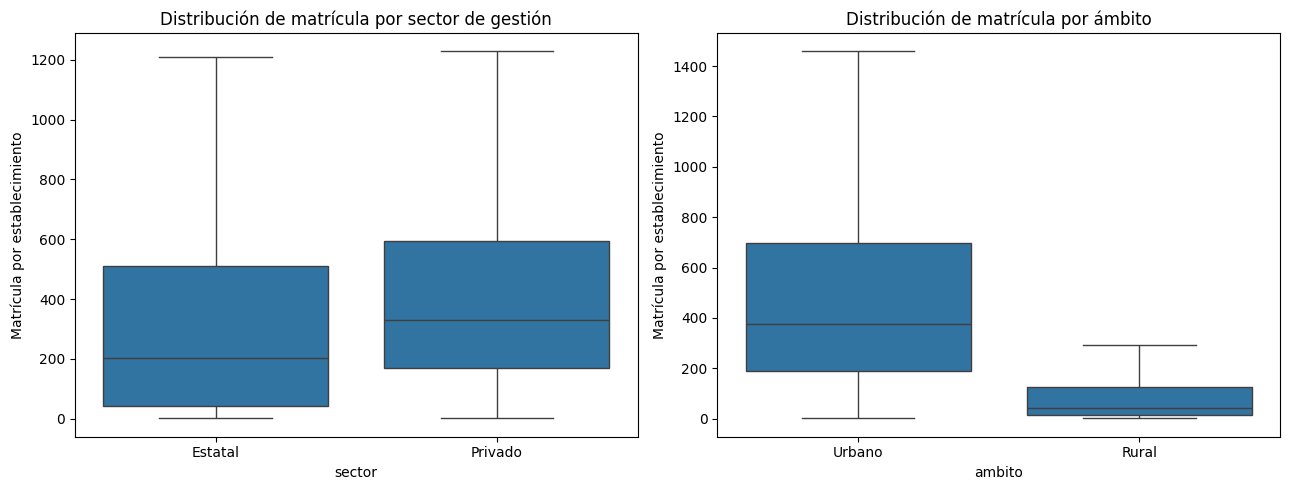

In [ ]:
# Matrícula por sector y ámbito
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_escuelas_tab, x='sector', y='matricula_total', ax=axes[0], showfliers=False)
axes[0].set_title('Distribución de matrícula por sector de gestión')
axes[0].set_ylabel('Matrícula por establecimiento')

sns.boxplot(data=df_escuelas_tab, x='ambito', y='matricula_total', ax=axes[1], showfliers=False)
axes[1].set_title('Distribución de matrícula por ámbito')
axes[1].set_ylabel('Matrícula por establecimiento')
plt.tight_layout(); plt.show()


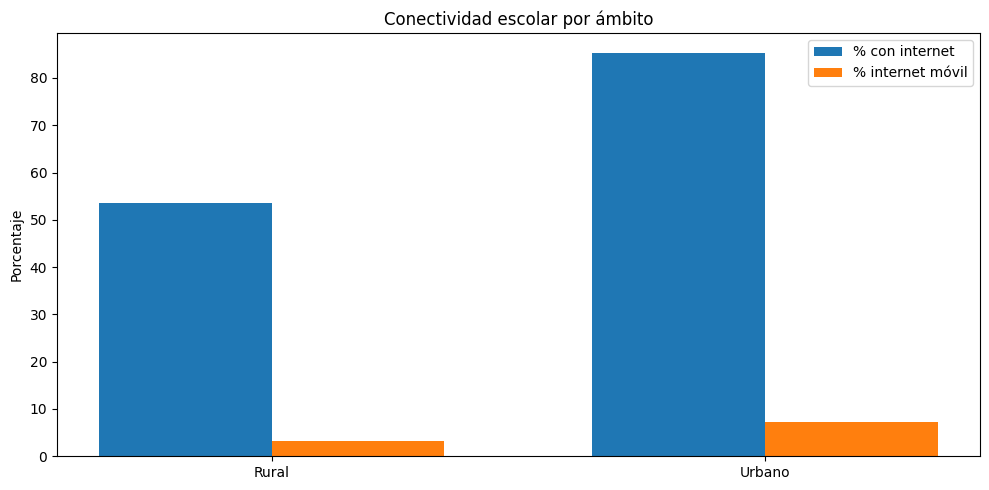

,ambito,pct_internet,pct_movil,matricula_prom
0,Rural,0.535643,0.032323,101.599223
1,Urbano,0.852734,0.071880,508.496330


In [ ]:
# Conectividad vs ámbito
conn = df_escuelas_tab.groupby('ambito').agg(
    pct_internet=('tiene_internet', 'mean'),
    pct_movil=('internet_movil', 'mean'),
    matricula_prom=('matricula_total', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(conn))
width = 0.35
ax1.bar(x - width/2, conn['pct_internet']*100, width, label='% con internet')
ax1.bar(x + width/2, conn['pct_movil']*100, width, label='% internet móvil')
ax1.set_xticks(x); ax1.set_xticklabels(conn['ambito'])
ax1.set_ylabel('Porcentaje'); ax1.set_title('Conectividad escolar por ámbito')
ax1.legend(); plt.tight_layout(); plt.show()

display(conn)


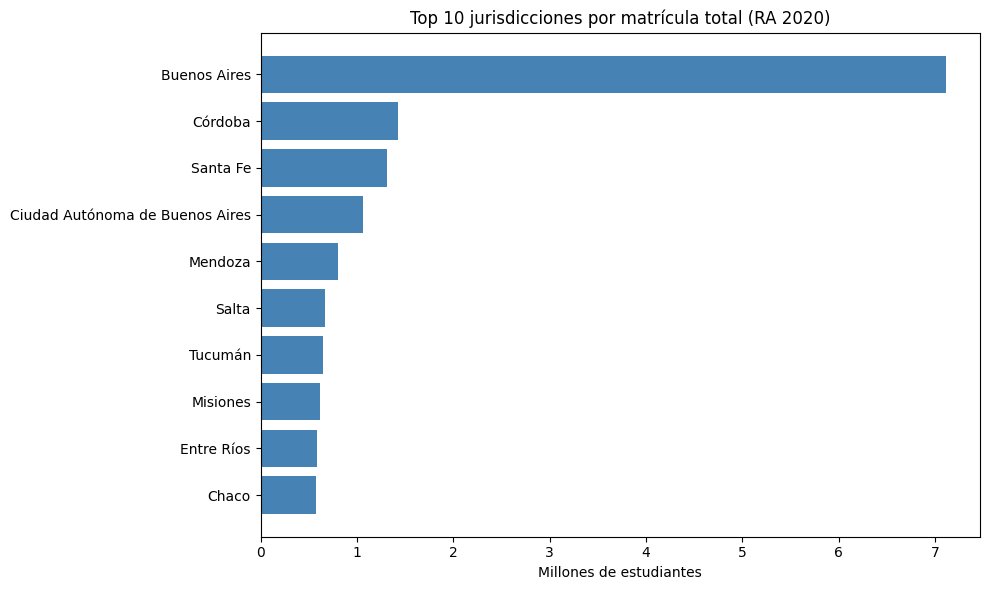

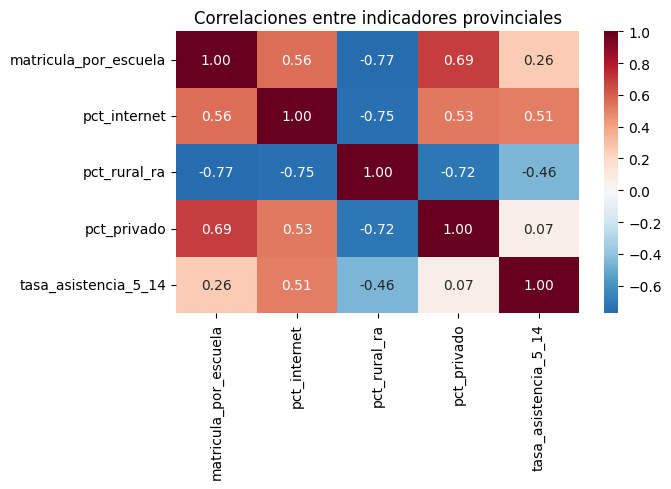

In [ ]:
# Top 10 provincias por matrícula y brecha de conectividad
rank = gdf_prov_ind.sort_values('matricula_total', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rank['nombre'], rank['matricula_total']/1e6, color='steelblue', label='Matrícula (millones)')
ax.set_xlabel('Millones de estudiantes')
ax.set_title('Top 10 jurisdicciones por matrícula total (RA 2020)')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

corr_cols = ['matricula_por_escuela', 'pct_internet', 'pct_rural_ra', 'pct_privado', 'tasa_asistencia_5_14']
corr = gdf_prov_ind[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlaciones entre indicadores provinciales')
plt.tight_layout(); plt.show()


## 6. Visualización geoespacial

Combinamos mapas coropléticos (provincia/departamento) y un mapa interactivo de densidad de establecimientos.


In [ ]:
# Provincias presentes en la tabla
print(df_caracteristicas['provincia'].unique())

['Mendoza' 'Misiones' 'Salta' 'San Juan' 'Santa Fe' 'Santiago del Estero'
 'Tucumán' 'Catamarca' 'Ciudad de Buenos Aires' 'Corrientes' 'Chaco'
 'Entre Ríos' 'Formosa' 'Jujuy' 'La Rioja' 'Neuquén' 'Buenos Aires'
 'Río Negro' 'Santa Cruz' 'Tierra del Fuego' 'Córdoba' 'Chubut' 'La Pampa'
 'San Luis']


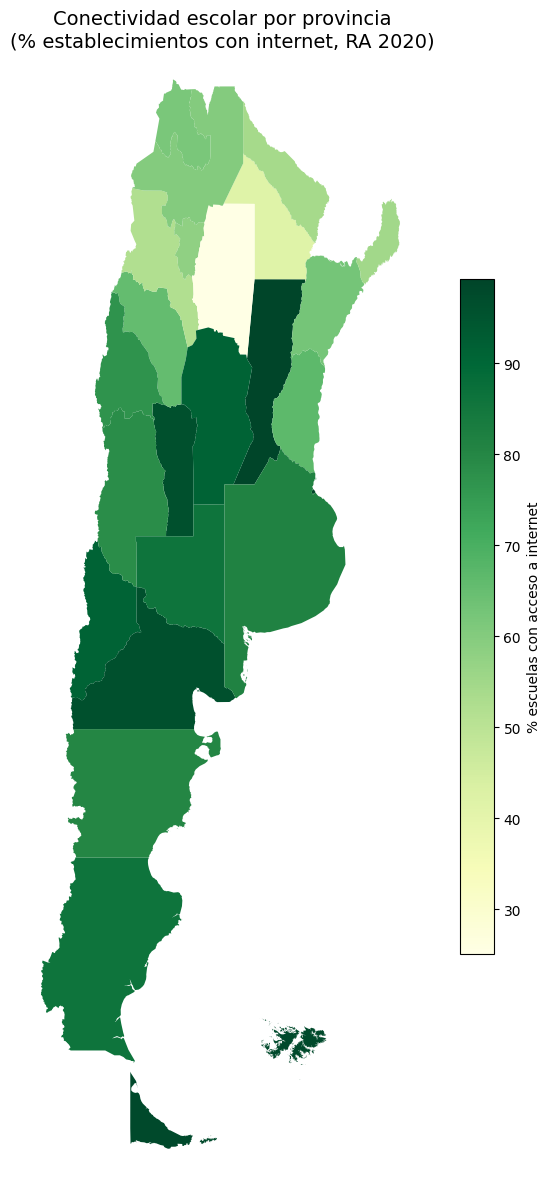

In [ ]:
# Mapa coroplético provincial: % escuelas con internet
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
gdf_plot = gdf_prov_ind.copy()
gdf_plot['pct_internet_pct'] = gdf_plot['pct_internet'] * 100
gdf_plot.plot(column='pct_internet_pct', ax=ax, legend=True, cmap='YlGn',
              legend_kwds={'label': '% escuelas con acceso a internet', 'shrink': 0.6},
              missing_kwds={'color': 'lightgrey'})
ax.set_title('Conectividad escolar por provincia\n(% establecimientos con internet, RA 2020)', fontsize=14)
# Sacamos la antartida de la visualizacion del mapa ya que solo mete ruido en el grafico
ax.set_xlim(-74, -53)
ax.set_ylim(-56, -21)
ax.set_axis_off()
plt.tight_layout(); plt.show()


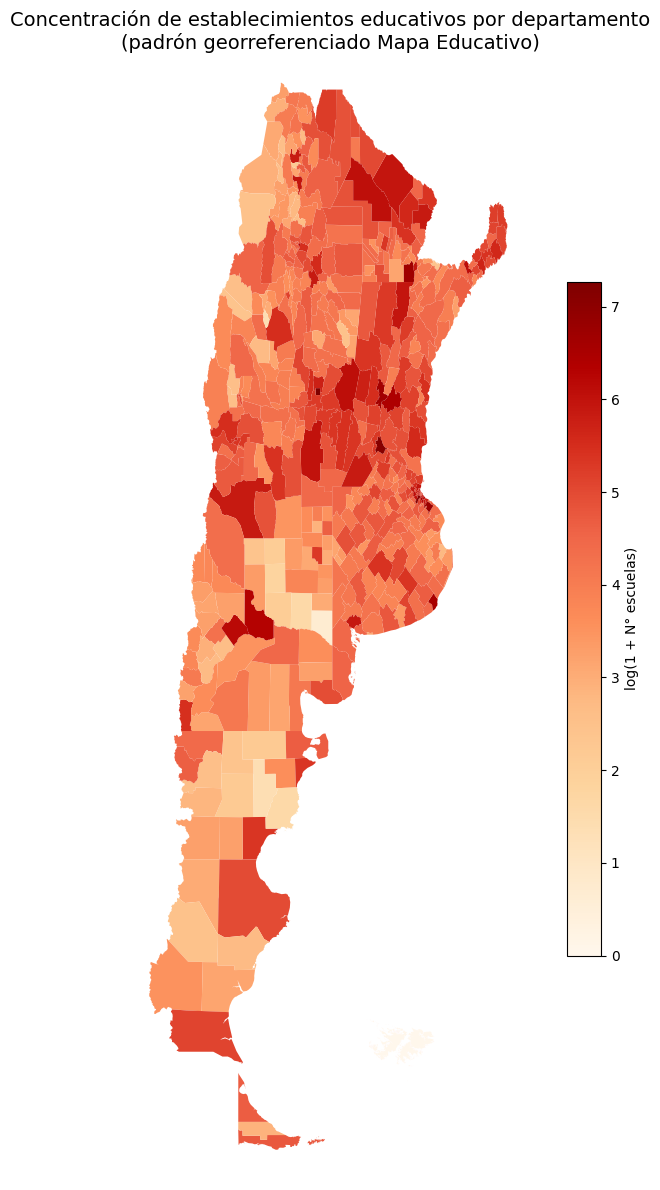

In [ ]:
# Mapa coroplético departamental: densidad de establecimientos (WFS)
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
gdf_dep_plot = gdf_dep_ind.copy()
gdf_dep_plot['log_escuelas'] = np.log1p(gdf_dep_plot['n_escuelas'])
gdf_dep_plot.plot(column='log_escuelas', ax=ax, legend=True, cmap='OrRd',
                  legend_kwds={'label': 'log(1 + N° escuelas)', 'shrink': 0.6},
                  missing_kwds={'color': 'lightgrey'})
ax.set_title('Concentración de establecimientos educativos por departamento\n(padrón georreferenciado Mapa Educativo)', fontsize=14)
# Sacamos la antartida de la visualizacion del mapa ya que solo mete ruido en el grafico
ax.set_xlim(-74, -53)
ax.set_ylim(-56, -21)
ax.set_axis_off()
plt.tight_layout(); plt.show()


In [ ]:
# Mapa interactivo Folium (muestra estratificada para performance)
np.random.seed(42)
muestra = gdf_escuelas_dep.sample(n=min(5000, len(gdf_escuelas_dep)), random_state=42)

m = folium.Map(location=[-38.5, -63.5], zoom_start=4, tiles='CartoDB positron')
cluster = MarkerCluster(name='Establecimientos').add_to(m)

color_map = {'Estatal': 'blue', 'Privado': 'red', 'Social/cooperativa': 'green'}

for _, row in muestra.iterrows():
    if row.geometry is None:
        continue
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color=color_map.get(row['gestion'], 'gray'),
        fill=True, fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row.get('nombre_est', '')}</b><br>Gestión: {row.get('gestion','')}<br>Ámbito: {row.get('ambito','')}<br>Depto: {row.get('departamento','')}",
            max_width=250
        )
    ).add_to(cluster)

folium.LayerControl().add_to(m)
m


Output hidden; open in https://colab.research.google.com to view.

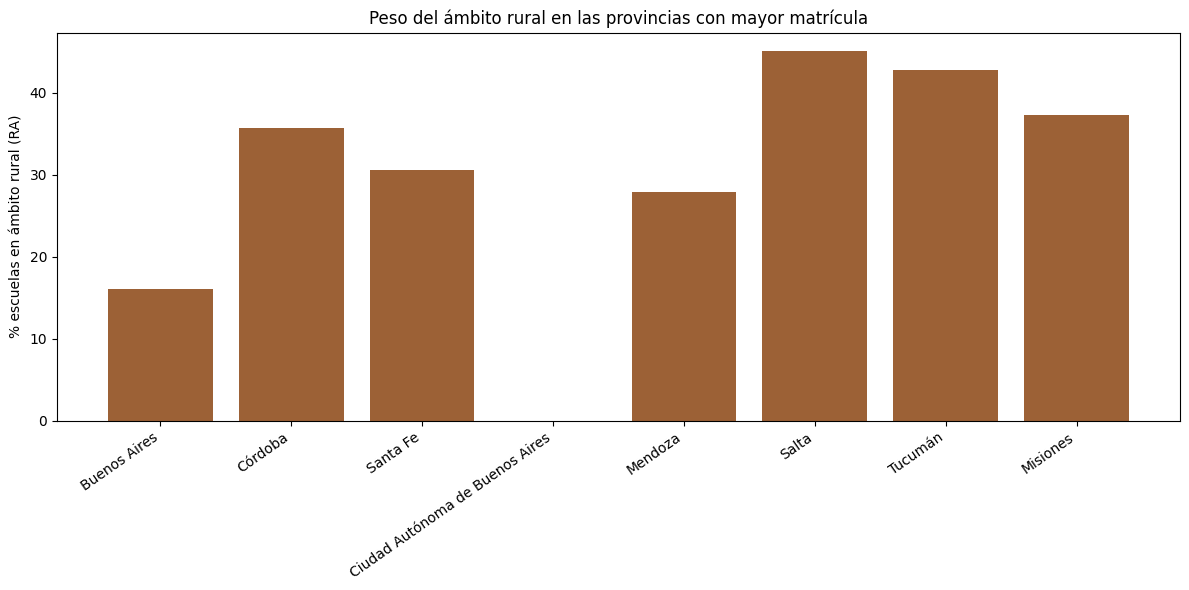

In [ ]:
# Comparativa urbano-rural por provincia (top 8 por matrícula)
top8 = gdf_prov_ind.nlargest(8, 'matricula_total')
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top8))
ax.bar(x, top8['pct_rural_ra']*100, color='saddlebrown', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top8['nombre'], rotation=35, ha='right')
ax.set_ylabel('% escuelas en ámbito rural (RA)')
ax.set_title('Peso del ámbito rural en las provincias con mayor matrícula')
plt.tight_layout(); plt.show()


Generando análisis y gráficos complementarios...
Validación de unión: Matrícula x Características (por provincia)
Filas df izquierdo : 24
Filas df derecho   : 24
Filas resultado    : 24
Claves únicas izquierda : 24
Claves únicas derecha   : 24
Claves sin match (izq -> no está en der): 0
Claves sin match (der -> no está en izq): 0



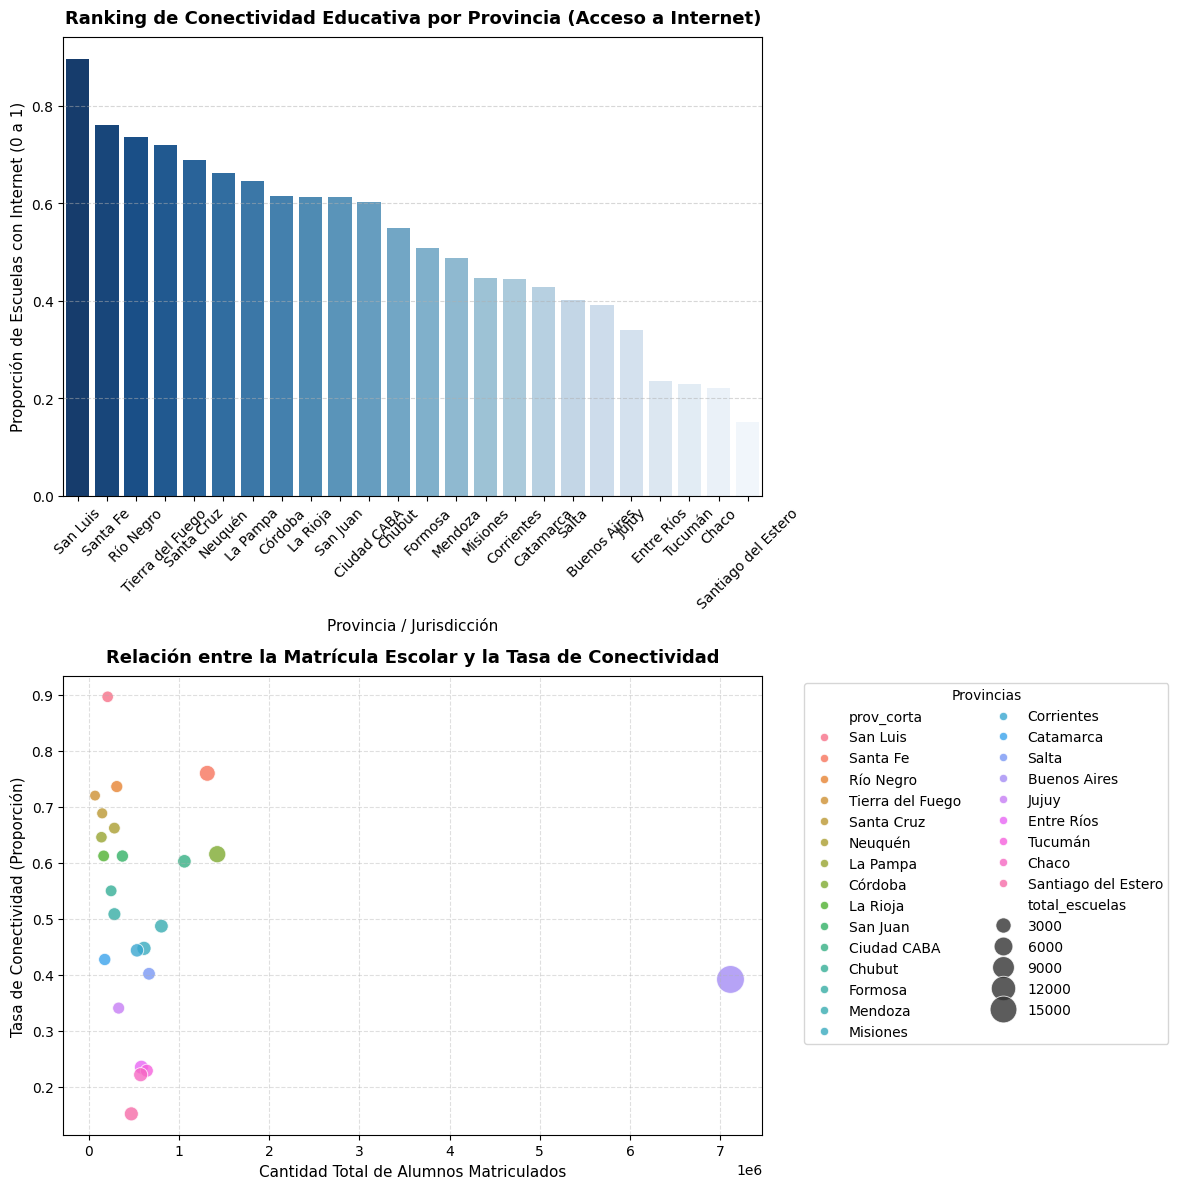


¡Visualizaciones generadas con total éxito!


In [ ]:

# Nuevos graficos para analisis

print("Generando análisis y gráficos complementarios...")

try:

    df_m = df_matricula.copy()
    df_c = df_caracteristicas.copy()


    df_m.columns = df_m.columns.str.lower()
    df_c.columns = df_c.columns.str.lower()

    #se buscan columnas claves
    col_prov_m = [c for c in df_m.columns if 'juris' in c or 'prov' in c][0]
    col_prov_c = [c for c in df_c.columns if 'juris' in c or 'prov' in c][0]
    col_mat = [c for c in df_m.columns if 'matr' in c or 'total' in c or 'alumn' in c][0]
    col_int = [c for c in df_c.columns if 'inter' in c or 'conec' in c or 'acc' in c][0]
    col_id = [c for c in df_c.columns if 'cue' in c or 'id' in c][0]

    # procesamiento de la conectividad (si dice 'Sí', 'si', o 'X' es 1, sino 0)
    df_c['tiene_internet_ok'] = df_c[col_int].apply(lambda x: 1 if str(x).strip().lower() in ['sí', 'si', 's', '1', 'x'] else 0)

    # Por provincia
    df_prov_m_agg = df_m.groupby(col_prov_m, as_index=False)[col_mat].sum()
    df_prov_c_agg = df_c.groupby(col_prov_c, as_index=False).agg(
        total_escuelas=(col_id, 'count'),
        con_internet=('tiene_internet_ok', 'sum')
    )

    # union de todo en nuestra propia tabla de gráficos
    df_para_graficos = pd.merge(df_prov_m_agg, df_prov_c_agg, left_on=col_prov_m, right_on=col_prov_c)

    # Chequeo de la unión: detecta provincias que no matchearon o filas perdidas
    validar_merge(df_prov_m_agg, df_prov_c_agg, df_para_graficos, col_prov_m, col_prov_c, nombre='Matrícula x Características (por provincia)')
    df_para_graficos['tasa_conectividad'] = df_para_graficos['con_internet'] / df_para_graficos['total_escuelas']


    df_para_graficos['prov_corta'] = df_para_graficos[col_prov_m].astype(str).str.replace('Provincia de ', '', case=False).str.replace('de Buenos Aires', 'CABA', case=False)
    df_para_graficos = df_para_graficos.sort_values(by='tasa_conectividad', ascending=False)


    fig, axes = plt.subplots(2, 1, figsize=(12, 12))

    # Gráfico 1: Barras
    sns.barplot(data=df_para_graficos, x='prov_corta', y='tasa_conectividad', palette='Blues_r', ax=axes[0])
    axes[0].set_title('Ranking de Conectividad Educativa por Provincia (Acceso a Internet)', fontsize=13, fontweight='bold', pad=10)
    axes[0].set_xlabel('Provincia / Jurisdicción', fontsize=11)
    axes[0].set_ylabel('Proporción de Escuelas con Internet (0 a 1)', fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Gráfico 2: Dispersión
    sns.scatterplot(
        data=df_para_graficos,
        x=col_mat,
        y='tasa_conectividad',
        size='total_escuelas',
        hue='prov_corta',
        sizes=(60, 400),
        alpha=0.8,
        ax=axes[1]
    )
    axes[1].set_title('Relación entre la Matrícula Escolar y la Tasa de Conectividad', fontsize=13, fontweight='bold', pad=10)
    axes[1].set_xlabel('Cantidad Total de Alumnos Matriculados', fontsize=11)
    axes[1].set_ylabel('Tasa de Conectividad (Proporción)', fontsize=11)
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Provincias', ncol=2)
    axes[1].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()
    print("\n¡Visualizaciones generadas con total éxito!")

except Exception as e:
    print(f"Ocurrió un detalle técnico: {e}")
    print("Por favor, asegúrate de ir arriba al menú 'Entorno de ejecución' -> 'Ejecutar todas' para que Colab cargue las tablas en memoria.")

# 7. Hallazgos, limitaciones y conclusiones

## Hallazgos

### Distribución de Escuelas por Ámbito y Gestión (Gráfico 1)

Las escuelas rurales son casi en su totalidad estatales, mientras que en las ciudades la oferta se reparte entre estatales y privadas. Dado que la oferta rural es predominantemente estatal, las mejoras o deficiencias en la infraestructura pública tienen un impacto especialmente relevante sobre estas comunidades educativas.

### Conectividad Escolar por Ámbito (Gráfico 2)

Los datos sugieren que el acceso mediante internet móvil presenta limitaciones para garantizar conectividad escolar sostenida, especialmente en ámbitos rurales.

### Top 10 de Jurisdicciones por Matrícula Total (Gráfico 3)

La Provincia de Buenos Aires concentra una cantidad significativamente mayor de alumnos frente al resto del país, seguida por Córdoba, Santa Fe y CABA.

Existe una enorme asimetría en la escala de gestión. El sistema educativo argentino está centralizado demográficamente en el bloque central del país. Esto significa que los desafíos para implementar políticas públicas o infraestructura tecnológica no son iguales para todos: las provincias grandes enfrentan un problema de volumen masivo, mientras que las provincias más chicas manejan escalas más controlables.

### Matriz de Correlación entre Indicadores (Gráfico 4)

A medida que un entorno es más rural, la presencia de la educación privada desaparece.  

Que una provincia tenga más o menos alumnos no influye en la tasa de asistencia ni garantiza que tenga mejor internet.

El porcentaje de escuelas privadas que tenga una provincia tampoco cambia la aguja de la asistencia general. El ausentismo y la falta de conectividad son desafíos estructurales que no se resuelven solos por el hecho de tener un sistema más grande o más privado.

### Comparativa urbano-rural por provincia (top 8 por matrícula)

No todas las provincias del "Top 8" son iguales. Mientras que en CABA la ruralidad es cero y en Buenos Aires es un porcentaje muy chico respecto al total, en provincias como Salta o Mendoza la educación rural sostiene a una parte muy importante de su población infantil. Por ende, estas provincias no pueden aplicar las mismas recetas que Buenos Aires; necesitan estrategias bimodales (urbanas y rurales en paralelo).

### Ranking de Conectividad Educativa por Provincia

El análisis evidencia importantes diferencias territoriales en el acceso a la educación digital. La provincia y el territorio constituyen factores determinantes en las oportunidades de acceso a herramientas digitales. Los resultados sugieren la ausencia de un estándar homogéneo de conectividad educativa a nivel nacional

### Relación entre la matrícula escolar y la tasa de conectividad

Queda demostrado visualmente que tener un sistema educativo grande o con muchos estudiantes no garantiza que el Estado o los privados inviertan más en conectar las escuelas. La conectividad es un problema de gestión y geografía, no de cuántos chicos vayan a clase.
1. **Concentración territorial:** la matrícula y la cantidad de establecimientos se concentran en las jurisdicciones del AMBA, Córdoba, Santa Fe y Mendoza, mientras que la Patagonia y el NOA presentan menor densidad escolar por departamento.
2. **Brecha urbano-rural:** el ámbito rural muestra menor proporción de escuelas con conectividad, especialmente acceso móvil/ADSL, lo que confirma una desigualdad estructural en infraestructura digital.
3. **Gestión pública vs privada:** el sector privado tiene presencia significativa en el AMBA y centros urbanos, pero la matrícula total sigue liderada por establecimientos estatales en la mayoría de las provincias.
4. **Coherencia entre fuentes:** los conteos del padrón georreferenciado (WFS) y las bases del Relevamiento Anual son comparables a nivel provincial, validando la integración espacial.

### Limitaciones

- Las bases por escuela 2024 requieren descarga manual desde SharePoint; se utilizó **RA 2020** por reproducibilidad automática.
- El cruce WFS ↔ RA no es escuela-a-escuela (distintos identificadores: CUE vs ID1); el análisis integrado se realiza a **nivel provincial/departamental**.
- Los indicadores de conectividad provienen de autodeclaración institucional del RA, no de medición técnica in situ.
- El mapa interactivo usa una **muestra** de 5.000 puntos para tiempos de renderizado aceptables en notebook.

### Conclusiones

El análisis territorial evidencia que la desigualdad educativa argentina no es sólo de matrícula, sino de **capacidad institucional** (conectividad, equipamiento y densidad de oferta). Las visualizaciones geoespaciales permiten identificar jurisdicciones donde la política pública debería priorizar inversión en conectividad rural y refuerzo de la red de establecimientos.

### Referencias

- Portal Nacional de Datos Públicos: https://datos.gob.ar/
- API Georef / IGN: https://www.ign.gob.ar/ y https://apis.datos.gob.ar/georef/api/v2.0/
- Mapa Educativo Nacional: https://mapa.educacion.gob.ar/
- Documentación: pandas, GeoPandas, Matplotlib, Folium (ver consigna del TP).
